In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters

## Part 1: Laplacian for Image Enhancement
The Laplacian operator measures **second-order intensity variation** and provides
an **orientation-independent** measure of local change.

### Key properties:
- Flat regions → Laplacian response near zero
- Rapid intensity changes (edges, fine detail) → large response
- Sensitive to noise due to second derivatives

### Discrete Laplacian (positive center):
$
\text{L} =
\begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}
$

### Image enhancement using Laplacian:
A common enhancement strategy is:

$I_{\text{sharp}} = I + \alpha (I * L)\$

where:
- $ I $ is the input image
- $ * $ denotes convolution
- $ \alpha > 0 $ controls enhancement strength

Using **linearity of convolution**, this can be rewritten as a **single filtering** operation:
$I_{\text{sharp}} ​= I ∗  (δ + αL)$

where $δ$ is the identity (impulse) filter.

In this part, we'll construct the combined filter matrix $(δ + αL)$ and apply it in one convolution step.

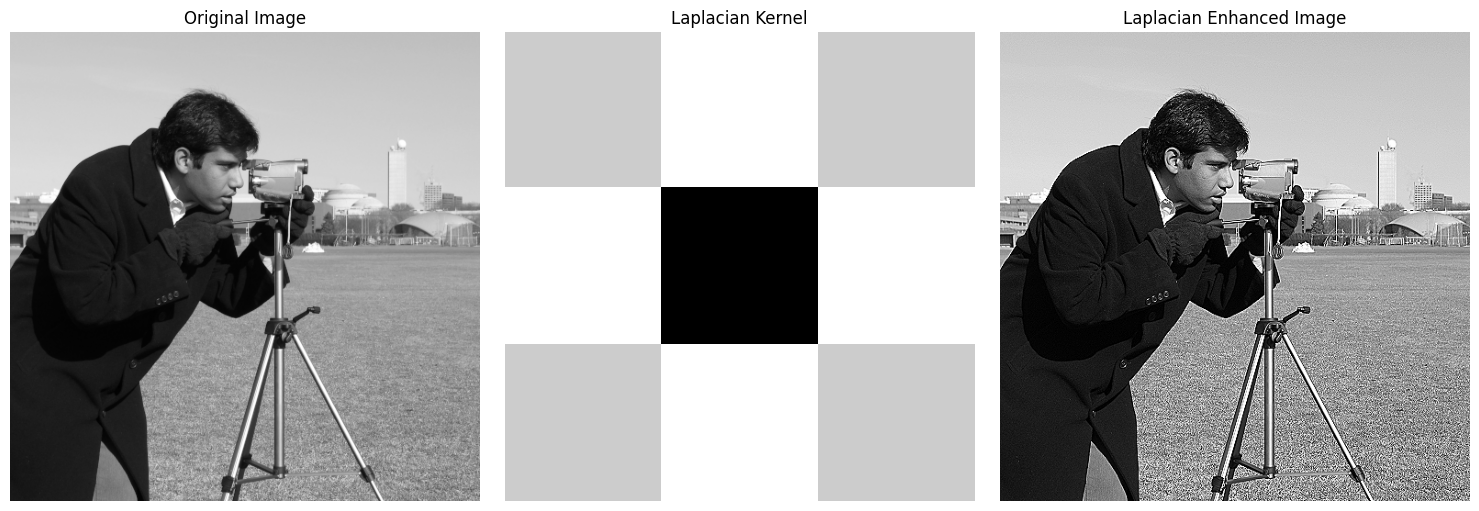

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, img_as_float

# Load example image
I = img_as_float(data.camera())

L = np.array([[0,1,0],[1,-4,1],[0,1,0]])
delta = np.array([[0,0,0],[0,1,0],[0,0,0]])
alpha = 1.0
combined_filter = delta-alpha*L
I_sharp = ndi.convolve(I,combined_filter)
I_sharp = np.clip(I_sharp,0,1)

fig,axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(I, cmap='gray',vmin=0, vmax=1)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(L, cmap='gray')
axes[1].set_title('Laplacian Kernel')
axes[1].axis('off')

axes[2].imshow(I_sharp, cmap='gray',vmin=0, vmax=1)
axes[2].set_title('Laplacian Enhanced Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Part 2: Combining Gaussian and Laplacian Filters (LoG)


### Motivation
- The Laplacian filter $L$ is sensitive to noise
- Smoothing before applying Laplacian improves robustness

Instead of applying two filters sequentially:
$(I * G) * L$

We combine both steps into **one linear filter**:
$
(I * G) * L = I * (G * L)
$

### Defining Laplacian of Gaussian (LoG):
$
\text{LoG} = G * L
$

Applying LoG in one step:

$
I_{\text{LoG}} = I * \text{LoG}
$

This suppresses noise while emphasizing fine-scale detail.

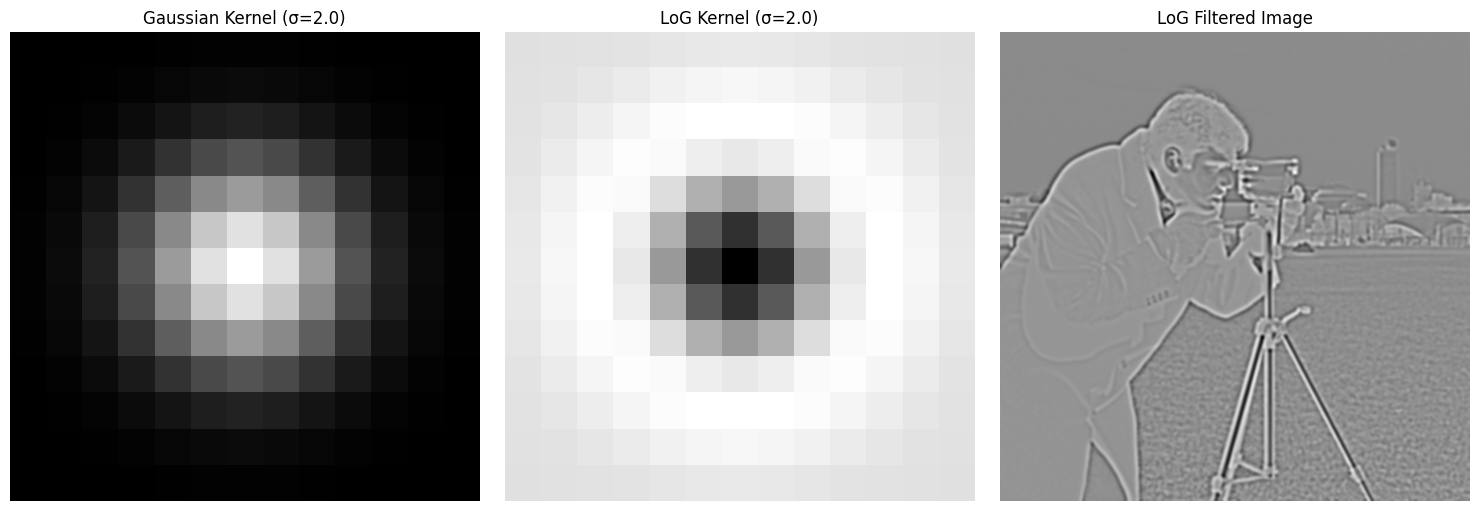

In [ ]:
from scipy.signal import convolve2d

def gaussian_kernel(size, sigma):
  ax=np.arange(-(size//2), size//2+1)
  xx,yy=np.meshgrid(ax,ax)
  kernel=np.exp(-(xx**2+yy**2)/(2*sigma**2))
  return kernel/kernel.sum()

sigma=2.0
kernel_size=int(6*sigma+1)
if kernel_size%2==0:
  kernel_size+=1
L = np.array([[0,1,0],[1,-4,1],[0,1,0]])
G=gaussian_kernel(kernel_size,sigma)

LoG=convolve2d(G,L,mode='same')

I_LoG=convolve2d(I,LoG, mode='same', boundary='symm')
fig,axes = plt.subplots(1,3,figsize=(15,5))

# Visualization
axes[0].imshow(G,cmap='gray')
axes[0].set_title(f'Gaussian Kernel (σ={sigma})')
axes[0].axis('off')
axes[1].imshow(LoG,cmap='gray')
axes[1].set_title(f'LoG Kernel (σ={sigma})')
axes[1].axis('off')
axes[2].imshow(I_LoG,cmap='gray')
axes[2].set_title('LoG Filtered Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#pass

## Part 3: Gaussian Filter Size Should Depend on $σ$



A Gaussian filter is theoretically infinite, but in practice
it must be truncated to a finite kernel size.

### Key idea:
The kernel size must be large enough to include most of the values of the Gaussian.

A common rule of thumb: $\text{kernel size} \approx 6\sigma + 1$

If the kernel is too small:
- The Gaussian is poorly approximated
- Smoothing is ineffective
- Artifacts may appear

In this part, we'll visualize Gaussian kernels with different σ
values and observe how kernel size affects smoothing.

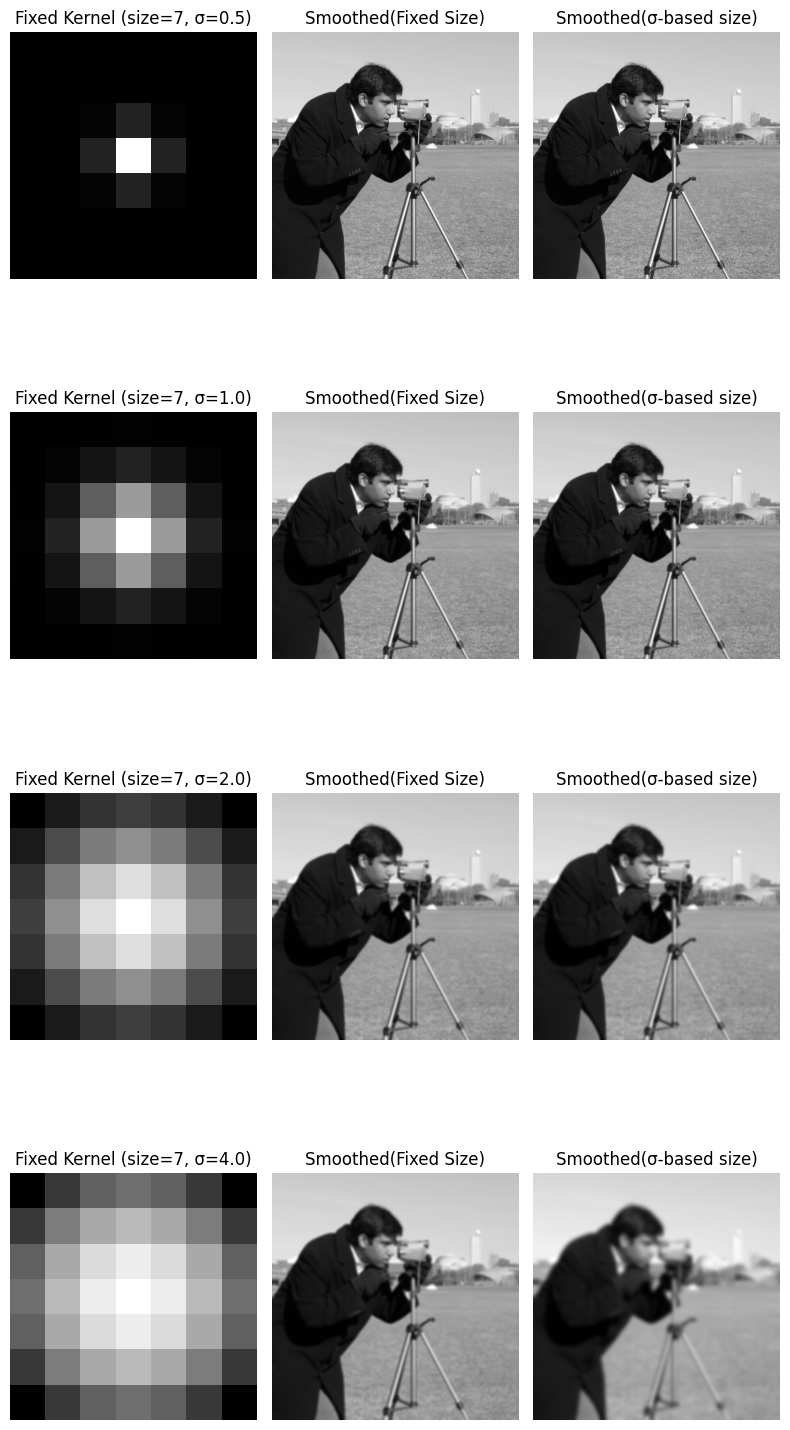

In [ ]:
from scipy.signal import convolve2d

# Fixed kernel size
fixed_size = 6

sigma_values=[0.5,1.0,2.0,4.0]

fig,axes = plt.subplots(len(sigma_values), 3, figsize=(8, 4 * len(sigma_values)))
for i, sigma in enumerate(sigma_values):
  fixed_kernel = gaussian_kernel(fixed_size+1, sigma)
  adaptive_size = int(6*sigma+1)
  if adaptive_size%2 == 0:
    adaptive_size+=1
  adaptive_kernel = gaussian_kernel(adaptive_size, sigma)
  I_fixed=convolve2d(I,fixed_kernel,mode='same',boundary='symm')
  I_adaptive=convolve2d(I,adaptive_kernel, mode='same', boundary='symm')

  axes[i, 0].imshow(fixed_kernel, cmap='gray')
  axes[i, 0].set_title(f'Fixed Kernel (size={fixed_size+1}, σ={sigma})')
  axes[i, 0].axis('off')

  axes[i, 1].imshow(I_fixed, cmap='gray')
  axes[i, 1].set_title(f'Smoothed(Fixed Size)')
  axes[i, 1].axis('off')

  axes[i, 2].imshow(I_adaptive, cmap='gray')
  axes[i, 2].set_title(f'Smoothed(σ-based size)')
  axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
#pass

## Part 4 — Bilateral Filtering (Edge-Aware Smoothing)

The Gaussian filter smooths an image by averaging nearby pixels using
distance-based weights only. As a result, it tends to blur edges.

The **bilateral filter** improves on this by combining:
- a **spatial Gaussian** (nearby pixels matter more), and
- a **range Gaussian** (similar-intensity pixels matter more).

This makes the filter **edge-aware** and **non-linear**.

In this part, we'll implement a bilateral filter from scratch and
compare it with the built-in implementation.

1. Implement bilateral filtering using explicit loops over pixel locations
2. Compute spatial weights using a fixed Gaussian kernel
3. Compute range weights based on intensity differences
4. Normalize the result correctly
5. Compare with `denoise_bilateral`

#### Constraints:
- No built-in filtering or convolution functions
- No vectorization across the image


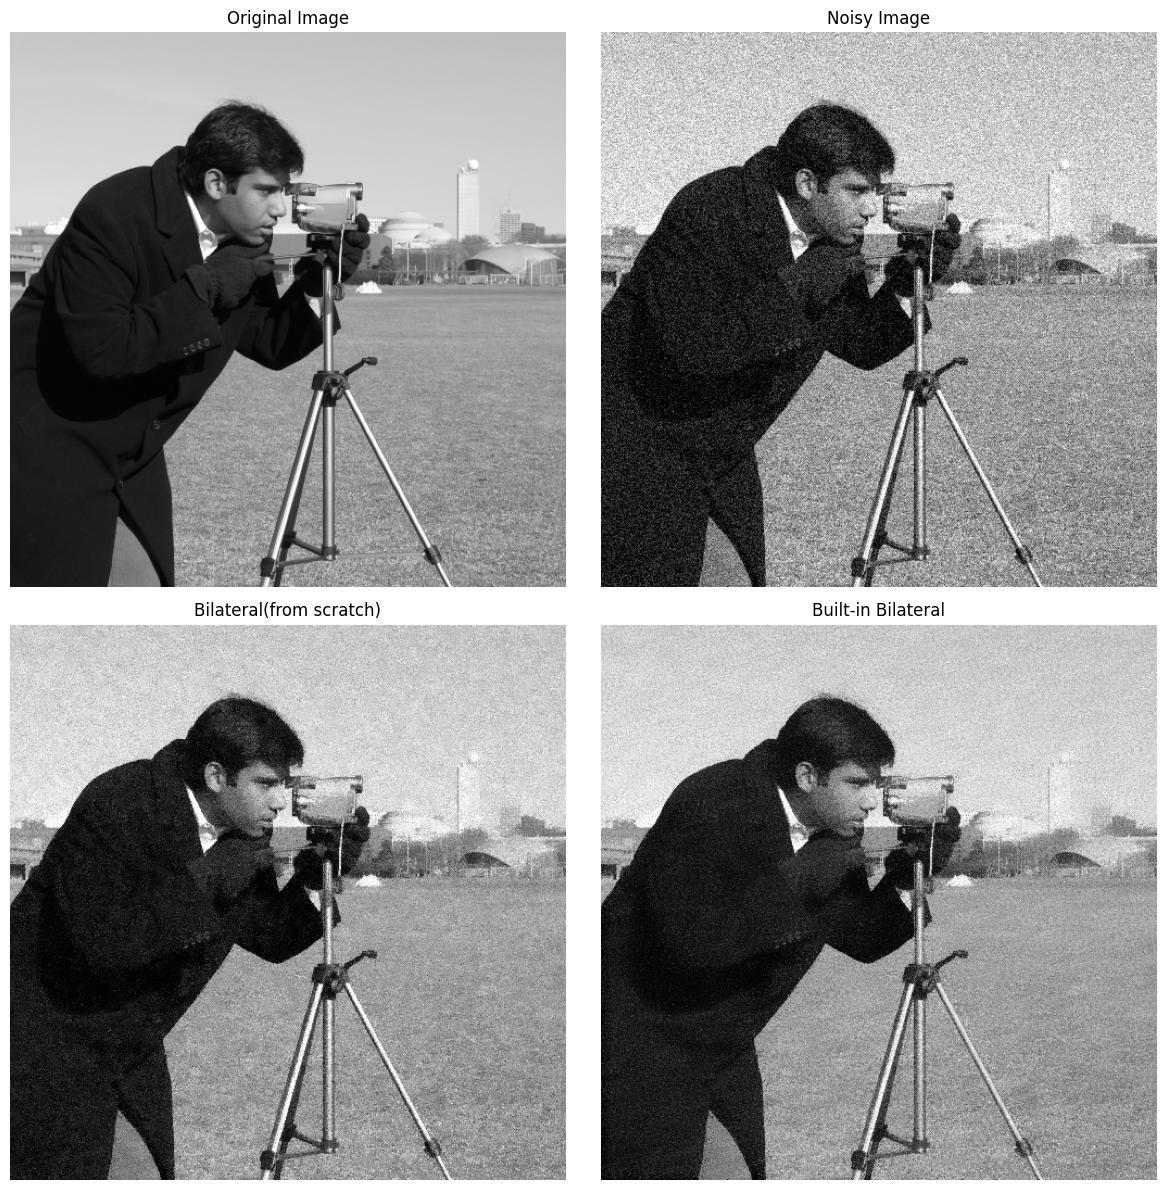

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util
from skimage.restoration import denoise_bilateral

I = img_as_float(data.camera())
noisy = util.random_noise(I,mode='gaussian', var=0.01)


sigma_spatial = 3.0
sigma_range = 0.1
kernel_size = int(6*sigma_spatial+1)
if kernel_size%2==0:
  kernel_size+=1
half = kernel_size // 2

# Spatial Gaussian kernel
x = np.arange(-half, half + 1)
y = np.arange(-half, half + 1)
X, Y = np.meshgrid(x, y)
G_spatial = np.exp(-(X**2 + Y**2) / (2 * sigma_spatial**2))

padded = np.pad(noisy,half,mode='reflect')

rows, cols = noisy.shape
bilateral_result = np.zeros_like(noisy)
for i in range(rows):
  for j in range(cols):
    window = padded[i:i+kernel_size, j:j+kernel_size]
    center_val = noisy[i,j]
    G_range = np.exp(-((window - center_val)**2) / (2 * sigma_range**2))
    weights = G_spatial*G_range
    bilateral_result[i,j] = np.sum(weights*window)/np.sum(weights)

builtin_bilateral = denoise_bilateral(noisy, sigma_color=sigma_range, sigma_spatial=sigma_spatial, channel_axis = None)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(I, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy, cmap='gray')
axes[0, 1].set_title('Noisy Image')
axes[0, 1].axis('off')

axes[1, 0].imshow(bilateral_result, cmap='gray')
axes[1, 0].set_title('Bilateral(from scratch)')
axes[1, 0].axis('off')

axes[1, 1].imshow(builtin_bilateral, cmap='gray')
axes[1, 1].set_title('Built-in Bilateral')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
#pass